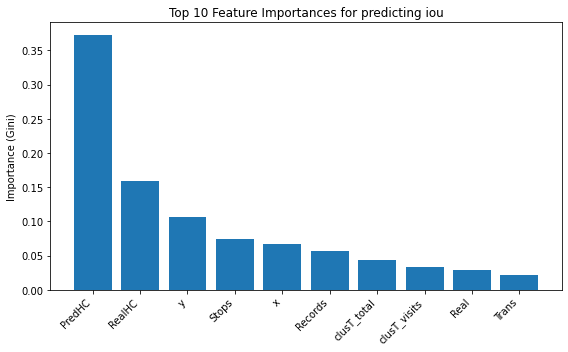

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv('predrealh.csv')
df = df.drop(columns=['annot'])
# Prepare features
features = df.drop(columns=['Unnamed: 0', 'iou'])
features['pareto'] = features['pareto'].astype(int)
features = features.fillna(features.median(numeric_only=True))

feature_cols = features.columns.tolist()

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

scaler = StandardScaler()
X_all = scaler.fit_transform(features)
y_all = df['iou'].values

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_all, y_all)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.bar(range(len(indices)), importances[indices], tick_label=[feature_cols[i] for i in indices])
plt.ylabel("Importance (Gini)")
plt.title("Top 10 Feature Importances for predicting iou")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()



GradientBoostingRegressor top‑1 accuracy: 0.0000
MRR: 0.0807
nDCG: 0.9844


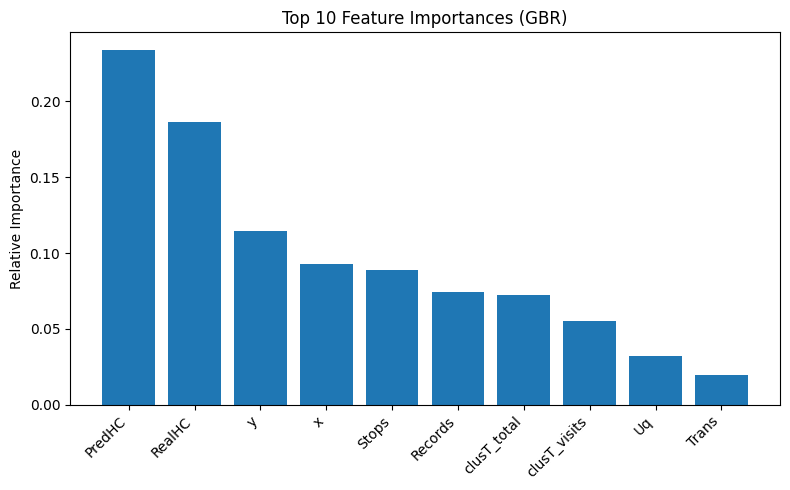

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

# 1. LOAD & PREP
df = pd.read_csv('predrealh.csv')

# expand annot column into three numeric cols
# annot_exp = df['annot'].str.strip('[]').str.split(r'\s*,\s*', expand=True).astype(float)
# annot_exp.columns = ['annot_0', 'annot_1', 'annot_2']
df = df.drop(columns=['annot'])


y = df['iou'].values
groups = df['Unnamed: 0'].values
X = df.drop(columns=['iou', 'Unnamed: 0']).copy()

# basic transforms
count_cols = ['Stops', 'Records', 'clusT_total', 'clusT_visits', 'RealHC', 'PredHC']
for c in count_cols:
    X[c] = np.log1p(X[c])

X['pareto'] = X['pareto'].astype(int)
X = X.fillna(0.0)
feature_names = X.columns.tolist()
X_mat = X.values

# 2. GROUP‑K‑FOLD CV + GBR (fast baseline ranking)
cv = GroupKFold(n_splits=5)
top1_scores, mrr_scores, ndcg_scores = [], [], []

for train_idx, test_idx in cv.split(X_mat, y, groups):
    gbr = GradientBoostingRegressor(random_state=42)
    gbr.fit(X_mat[train_idx], y[train_idx])
    y_pred = gbr.predict(X_mat[test_idx])

    df_test = pd.DataFrame({
        'group': groups[test_idx],
        'true': y[test_idx],
        'pred': y_pred
    })

    top1_correct = 0
    mrr_accum = 0.0
    ndcg_accum = 0.0
    grp_cnt = 0

    for g, g_df in df_test.groupby('group'):
        grp_cnt += 1
        idx_best_true = g_df['true'].idxmax()
        idx_best_pred = g_df['pred'].idxmax()
        if idx_best_true == idx_best_pred:
            top1_correct += 1

        ranks = g_df['pred'].rank(method='first', ascending=False)
        rank_true = ranks.loc[idx_best_true]
        mrr_accum += 1.0 / rank_true

        true_rel = g_df[['true']].T.values
        pred_score = g_df[['pred']].T.values
        ndcg_accum += ndcg_score(true_rel, pred_score)

    top1_scores.append(top1_correct / grp_cnt)
    mrr_scores.append(mrr_accum / grp_cnt)
    ndcg_scores.append(ndcg_accum / grp_cnt)

print(f"GradientBoostingRegressor top‑1 accuracy: {np.mean(top1_scores):.4f}")
print(f"MRR: {np.mean(mrr_scores):.4f}")
print(f"nDCG: {np.mean(ndcg_scores):.4f}")

# 3. FEATURE IMPORTANCE
importances = gbr.feature_importances_
idx_sorted = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(8,5))
plt.bar(range(len(idx_sorted)), importances[idx_sorted], tick_label=np.array(feature_names)[idx_sorted])
plt.ylabel("Relative Importance")
plt.title("Top 10 Feature Importances (GBR)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [140]:
import pandas as pd, numpy as np

df = pd.read_csv("predrealh.csv")

# ────────────────────────────────────────────────────────────────
relevance = (df["iou"] * 100).round().astype(int).values

# keep groups and feature matrix exactly as before
y      = relevance                 # <- integer labels now!
groups = df["Unnamed: 0"].values
# X      = df.drop(columns=["iou", "Unnamed: 0","annot"]).copy()
X = df[['PredHC','RealHC']].copy()

# log-transform heavy-tailed counts
# count_cols = ["Stops"]
# X[count_cols] = np.log1p(X[count_cols])

# categorical/indicator
# X["pareto"] = X["pareto"].astype(int)

# final clean-up
X = X.fillna(0.0)
feature_names = X.columns.tolist()
X = X.values


In [141]:
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)

In [142]:
import lightgbm as lgb
import tqdm, collections, numpy as np

def group_sizes(ids):
    """turn row-level group id array into LightGBM 'group' list"""
    return list(collections.Counter(ids).values())

params = dict(
    objective      = "lambdarank",
    metric         = "ndcg",
    learning_rate  = 0.06,
    num_leaves     = 63,
    min_data_in_leaf = 15,
    feature_fraction = 0.8,
    bagging_fraction = 0.8,
    bagging_freq     = 1,
    verbose          = -1,
    seed             = 42,
)
max_grade = y.max()          # e.g. 100
params['label_gain'] = list(range(max_grade + 1))

top1, mrr, ndcg_scores = [], [], []

for fold, (tr, va) in enumerate(gkf.split(X, y, groups), 1):
    dtrain = lgb.Dataset(
        X[tr], label=y[tr],
        group=group_sizes(groups[tr]),
        feature_name=feature_names
    )
    booster = lgb.train(
        params, dtrain,
        num_boost_round = 700,   # ↑ after tuning
    )
    y_pred = booster.predict(X[va])

    # evaluate --------------------------------------------------
    df_va = pd.DataFrame({
        "gid":  groups[va],
        "true": y[va],
        "pred": y_pred
    })

    hit, reciprocal, ndcg_fold = 0, 0., 0.
    for _, gdf in df_va.groupby("gid"):
        best_true = gdf["true"].idxmax()
        best_pred = gdf["pred"].idxmax()
        if best_true == best_pred:
            hit += 1
        rank_true = gdf["pred"].rank(method="first", ascending=False).loc[best_true]
        reciprocal += 1.0 / rank_true

        # nDCG with sklearn
        from sklearn.metrics import ndcg_score
        ndcg_fold += ndcg_score(gdf[["true"]].T, gdf[["pred"]].T)

    n_groups = df_va["gid"].nunique()
    top1.append(hit / n_groups)
    mrr.append(reciprocal / n_groups)
    ndcg_scores.append(ndcg_fold / n_groups)

print(f"Top-1 accuracy : {np.mean(top1):.3f}")
print(f"MRR            : {np.mean(mrr):.3f}")
print(f"nDCG           : {np.mean(ndcg_scores):.3f}")
print(export_text(surrogate, feature_names=list(X_df.columns)))

Top-1 accuracy : 0.167
MRR            : 0.186
nDCG           : 0.966


In [93]:
df.iloc[[36,283,507]]

,Unnamed: 0,x,y,iou,annot,Stops,clusT_total,Records,Uq,Pred,Real,clusT_visits,Trans,RealHC,PredHC,pareto,distance,score
36,0,0.970551,0.279967,0.893503,"[50, 60, 50]",86.0,0.115875,103.0,19.0,0.624064,2.522746,0.113325,0.726140,0.153724,0.985084,False,0.942646,-2.616555
283,1,0.983037,0.205573,0.819596,"[100, 60, 300]",78.0,0.175700,100.0,31.0,0.573741,3.075859,0.177362,0.686071,0.170108,0.986251,False,0.763796,-2.876747
507,2,0.988132,0.138125,0.958244,"[100, 300, 100]",50.0,0.066540,58.0,14.0,0.609610,2.409666,0.065119,0.371367,0.098934,0.991802,False,0.980058,-0.388177


In [67]:
# 1.  fit on ALL data (we skip CV splits now) --------------------
final_train = lgb.Dataset(
    X, label=y, group=group_sizes(groups),
    feature_name=feature_names
)
final_model = lgb.train(params, final_train, num_boost_round=700)

# 2.  score every row -------------------------------------------
df["score"] = final_model.predict(X)

# 3.  choose arg-max per hidden group ----------------------------
best_rows = (
    df.loc[df.groupby("Unnamed: 0")["score"].idxmax()]
      .sort_values("Unnamed: 0")
)

# 4.  best_rows now holds ONE row per group — your “max-iou guess”
best_rows

,Unnamed: 0,x,y,iou,annot,Stops,clusT_total,Records,Uq,Pred,Real,clusT_visits,Trans,RealHC,PredHC,pareto,distance,score
38,0,0.970925,0.290316,0.965997,"[50, 60, 300]",98.0,0.120446,118.0,23.0,0.611135,2.698179,0.118337,1.057631,0.181394,0.982927,False,0.719926,12.367302
212,1,0.979332,0.255171,0.936576,"[30, 60, 100]",113.0,0.182238,129.0,46.0,0.525611,3.603380,0.184493,1.110231,0.190583,0.985094,True,1.004293,14.466768
469,2,0.988008,0.133564,0.985334,"[50, 180, 500]",64.0,0.070782,64.0,10.0,0.679708,1.920000,0.069388,0.265584,0.099686,0.991294,False,0.744658,10.891966
809,3,0.994353,0.059243,0.689576,"[1000, 60, 500]",11.0,0.020150,11.0,3.0,0.658134,1.268458,0.019823,0.028263,0.035197,0.996706,True,0.732647,1.357058
842,4,0.971705,0.287204,0.941880,"[30, 60, 100]",67.0,0.167115,69.0,15.0,0.695501,2.046059,0.168371,0.323303,0.165044,0.984917,True,0.995036,6.185990
1098,6,0.982490,0.172482,0.958054,"[50, 180, 300]",55.0,0.026623,56.0,6.0,0.706123,1.556038,0.025375,0.175073,0.097856,0.990684,True,0.877250,9.891315
1449,7,0.992590,0.082245,0.938453,"[1000, 180, 500]",19.0,0.029673,30.0,6.0,0.703330,1.566029,0.027544,0.147362,0.064550,0.994236,False,0.465586,8.783899
1588,8,0.956981,0.460515,0.891222,"[200, 180, 300]",117.0,0.125305,187.0,28.0,0.617582,2.778089,0.123629,0.905484,0.371297,0.966272,False,0.630424,8.149243
1753,9,0.972336,0.284909,0.957617,"[100, 60, 300]",80.0,0.190179,91.0,14.0,0.740978,1.783763,0.192810,0.347227,0.212507,0.980069,True,0.739670,12.340710
1978,11,0.978699,0.231904,0.914696,"[100, 300, 300]",68.0,0.173343,68.0,15.0,0.650985,2.262008,0.174006,0.458300,0.188547,0.983044,True,0.819237,5.758178


In [97]:
import optuna, lightgbm as lgb
from sklearn.model_selection import GroupKFold
import pandas as pd, numpy as np
true_iou = df["iou"].values    
# --------------------------------------------------
# helper: convert group id array -> list of group sizes
# --------------------------------------------------
def group_sizes(id_array):
    _, counts = np.unique(id_array, return_counts=True)
    return counts.tolist()

# --------------------------------------------------
# helper: metric we REALLY care about
# --------------------------------------------------
def iou_metrics(df, group_col='gid', iou_col='iou', pick_col='pred'):
    mean_iou, mean_ratio = 0.0, 0.0
    for _, gdf in df.groupby(group_col):
        best_idx   = gdf[pick_col].idxmax()
        chosen_iou = gdf.at[best_idx, iou_col]
        max_iou    = gdf[iou_col].max()
        mean_iou  += chosen_iou
        mean_ratio += chosen_iou / max_iou
    n = df[group_col].nunique()
    return mean_iou / n, mean_ratio / n

# --------------------------------------------------
# main Optuna objective
# --------------------------------------------------
def objective(trial):
    # 1)  hyper-parameters to search
    params = dict(
        objective          = "lambdarank",
        metric             = "ndcg",          # still needed by LightGBM but not our optimiser
        learning_rate      = trial.suggest_float("lr", 0.02, 0.15, log=True),
        num_leaves         = trial.suggest_int("num_leaves", 31, 255, log=True),
        min_data_in_leaf   = trial.suggest_int("min_data", 5, 50),
        feature_fraction   = trial.suggest_float("feat_frac", 0.6, 1.0),
        bagging_fraction   = trial.suggest_float("bag_frac", 0.6, 1.0),
        bagging_freq       = 1,
        seed               = 42,
        verbose            = -1,
    )
    max_grade = y.max()          # e.g. 100
    params['label_gain'] = list(range(max_grade + 1))

    # 2)  one fold is usually enough for quick tuning; change to GroupKFold(5) for robustness
    cv = GroupKFold(n_splits=3)
    ratios = []

    for train_idx, valid_idx in cv.split(X, y, groups):
        train_set = lgb.Dataset(
            X[train_idx], label=y[train_idx],
            group=group_sizes(groups[train_idx])
        )
        booster = lgb.train(params, train_set, num_boost_round=600)

        preds = booster.predict(X[valid_idx])
        df_val = pd.DataFrame({
            "gid" : groups[valid_idx],
            "iou" : true_iou[valid_idx],   # keep raw float IOU for metric
            "pred": preds
        })
        _, ratio = iou_metrics(df_val)
        ratios.append(ratio)

    # 3)  we want to MAXIMISE ratio  →  MINIMISE  (1 - ratio)
    return 1.0 - np.mean(ratios)


In [143]:
study = optuna.create_study(direction="minimize")   #  we minimise 1-ratio
study.optimize(objective, n_trials=60, show_progress_bar=True)

print("Best trial :", study.best_trial.number)
print("Best params:", study.best_params)
print("Achieved mean ratio :", 1 - study.best_value)


[I 2025-06-13 15:33:28,116] A new study created in memory with name: no-name-9057b2b1-98c3-495c-ad1e-80f85e85c04a


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2025-06-13 15:33:30,630] Trial 0 finished with value: 0.18599981974264246 and parameters: {'lr': 0.052013451798905944, 'num_leaves': 160, 'min_data': 6, 'feat_frac': 0.8992316052777195, 'bag_frac': 0.7438170456019912}. Best is trial 0 with value: 0.18599981974264246.
[I 2025-06-13 15:33:31,995] Trial 1 finished with value: 0.20356103477239096 and parameters: {'lr': 0.08337715920593748, 'num_leaves': 147, 'min_data': 38, 'feat_frac': 0.7867592423178491, 'bag_frac': 0.8809999353703275}. Best is trial 0 with value: 0.18599981974264246.
[I 2025-06-13 15:33:33,370] Trial 2 finished with value: 0.19857279104087633 and parameters: {'lr': 0.1178974946129128, 'num_leaves': 75, 'min_data': 29, 'feat_frac': 0.889604833676685, 'bag_frac': 0.9169000997248353}. Best is trial 0 with value: 0.18599981974264246.
[I 2025-06-13 15:33:35,527] Trial 3 finished with value: 0.19466526270894324 and parameters: {'lr': 0.06396966810200776, 'num_leaves': 98, 'min_data': 5, 'feat_frac': 0.7235178495953896, 'ba

[I 2025-06-13 15:34:26,654] Trial 31 finished with value: 0.20116351365755492 and parameters: {'lr': 0.02027180510965027, 'num_leaves': 52, 'min_data': 21, 'feat_frac': 0.7594923204728624, 'bag_frac': 0.9969300078989599}. Best is trial 21 with value: 0.17591871341985.
[I 2025-06-13 15:34:28,734] Trial 32 finished with value: 0.18191343451567243 and parameters: {'lr': 0.02305844863635268, 'num_leaves': 85, 'min_data': 22, 'feat_frac': 0.7496614683176991, 'bag_frac': 0.9501327187257254}. Best is trial 21 with value: 0.17591871341985.
[I 2025-06-13 15:34:29,962] Trial 33 finished with value: 0.1839784632616709 and parameters: {'lr': 0.030614666418862194, 'num_leaves': 35, 'min_data': 18, 'feat_frac': 0.6254013922358284, 'bag_frac': 0.9730219665628548}. Best is trial 21 with value: 0.17591871341985.
[I 2025-06-13 15:34:31,699] Trial 34 finished with value: 0.20089688113458404 and parameters: {'lr': 0.022038969647811928, 'num_leaves': 56, 'min_data': 27, 'feat_frac': 0.7929793025863237, 'ba

In [144]:
study

In [145]:
best_params = study.best_params
best_params.update({
    "objective": "lambdarank",
    "metric"    : "ndcg",
    "seed"      : 42,
    "verbose"   : -1,
    'label_gain': list(range(max_grade + 1))
})

final_set = lgb.Dataset(X, label=y, group=group_sizes(groups))
final_model = lgb.train(best_params, final_set, num_boost_round=800)

In [146]:
df["score"] = final_model.predict(X)
df

,Unnamed: 0,x,y,iou,annot,Stops,clusT_total,Records,Uq,Pred,Real,clusT_visits,Trans,RealHC,PredHC,pareto,distance,score
0,0,0.964942,0.324330,0.771064,"[30, 60, 30]",71.0,0.104893,82.0,15.0,0.618075,2.413515,0.100870,0.650484,0.158556,0.984537,False,1.002136,-5.415441
1,0,0.964537,0.320647,0.825432,"[30, 60, 50]",76.0,0.102976,83.0,14.0,0.600340,2.449668,0.098803,0.639796,0.156466,0.984380,False,1.002136,-6.337120
2,0,0.965618,0.330128,0.887591,"[30, 60, 100]",83.0,0.107382,87.0,15.0,0.600596,2.491271,0.103754,0.685509,0.171794,0.983700,False,0.983466,-4.551187
3,0,0.965428,0.331669,0.912433,"[30, 60, 300]",90.0,0.110773,95.0,16.0,0.629079,2.400524,0.107270,0.717816,0.165851,0.984352,False,0.900278,-5.615734
4,0,0.965961,0.332013,0.934623,"[30, 60, 500]",96.0,0.111849,102.0,18.0,0.605960,2.577983,0.108302,0.834895,0.179084,0.983178,True,0.908096,-2.848300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3775,19,0.993796,0.054413,0.211248,"[1000, 1200, 30]",1.0,-0.000000,1.0,1.0,0.999900,0.000000,-0.000000,0.000000,0.016310,0.999900,False,0.939704,-17.723491
3776,19,0.994432,0.055276,0.556120,"[1000, 1200, 50]",1.0,0.004593,4.0,2.0,0.500282,1.142857,0.002629,0.000000,0.029679,0.996974,False,0.937160,-17.311952
3777,19,0.994722,0.055890,0.692646,"[1000, 1200, 100]",2.0,0.009118,9.0,3.0,0.333333,1.584963,0.007265,0.083385,0.034604,0.996770,False,0.937160,-14.394483
3778,19,0.994715,0.055953,0.858482,"[1000, 1200, 300]",2.0,0.009303,12.0,3.0,0.721418,1.132093,0.008959,0.031381,0.043314,0.995811,False,0.937160,-13.346635


In [157]:
df.groupby('Unnamed: 0').iou.max()

Unnamed: 0
0     0.965997
1     0.939437
2     0.987102
3     0.690834
4     0.941880
6     0.958083
7     0.938453
8     0.891222
9     0.957617
11    0.916833
12    0.896948
13    0.947586
14    0.885289
15    0.990944
16    0.965925
17    0.922112
18    0.997898
19    0.998245
Name: iou, dtype: float64

In [147]:
chosen_idx = df.groupby('Unnamed: 0')["score"].idxmax()
chosen_df  = df.loc[chosen_idx].copy()          # one row per group
chosen_df['iou'].mean()

0.9287150611151629

In [164]:
df['Unnamed: 0'].unique()

array([ 0,  1,  2,  3,  4,  6,  7,  8,  9, 11, 12, 13, 14, 15, 16, 17, 18,
       19], dtype=int64)

In [168]:
compare = pd.concat((chosen_df[['x','y','iou','annot','Stops','max_iou','PredHC','RealHC']].reset_index(drop=True),df.groupby('Unnamed: 0').iou.max().reset_index(drop=True)),axis=1)
ious = compare[['iou']]
ious.columns = ['pred','true']
ious.iloc[:,1] - ious.iloc[:,0]

0     0.000000
1     0.002861
2     0.001767
3     0.000104
4     0.000000
5     0.000230
6     0.016873
7     0.044310
8     0.000000
9     0.005132
10    0.000000
11    0.000137
12    0.000000
13    0.004019
14    0.000102
15    0.000000
16    0.000000
17    0.000000
dtype: float64

Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty Da

In [148]:
import shap
explainer = shap.TreeExplainer(final_model)   # booster is the trained LightGBM model

In [149]:
X_df = pd.DataFrame(X,columns=feature_names)

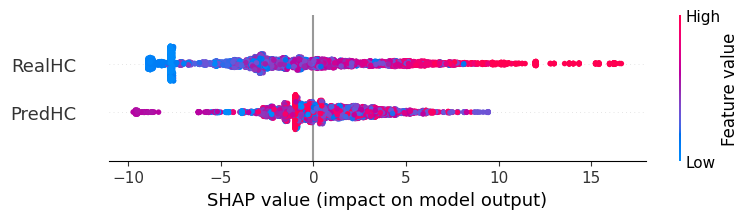

In [150]:
shap_values = explainer.shap_values(X)     # shape: (n_rows, n_features)

shap.summary_plot(shap_values, X_df, show=False)

In [151]:
from explainerdashboard import RegressionExplainer, ExplainerDashboard

In [152]:
# Create SHAP explainer for tree-based models
explainer = RegressionExplainer(final_model, X_df, y)

Generating self.shap_explainer = shap.KernelExplainer(model, X)...


In [153]:
db1 = ExplainerDashboard(explainer)

Building ExplainerDashboard..
Detected notebook environment, consider setting mode='external', mode='inline' or mode='jupyterlab' to keep the notebook interactive while the dashboard is running...
For this type of model and model_output interactions don't work, so setting shap_interaction=False...
The explainer object has no decision_trees property. so setting decision_trees=False...
Generating layout...
Calculating shap values...


  0%|          | 0/3780 [00:00<?, ?it/s]

Calculating predictions...
Calculating residuals...
Calculating absolute residuals...
Calculating dependencies...
Calculating importances...
Reminder: you can store the explainer (including calculated dependencies) with explainer.dump('explainer.joblib') and reload with e.g. ClassifierExplainer.from_file('explainer.joblib')
Registering callbacks...


C:\Users\kamil\AppData\Roaming\Python\Python39\site-packages\sklearn\metrics\_scorer.py:548: FutureWarning:

The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.



In [154]:
db1.run()

Starting ExplainerDashboard on http://192.168.1.199:8050


ConnectionError: HTTPConnectionPool(host='0.0.0.0', port=8050): Max retries exceeded with url: /_alive_6ec5b764-d2a6-49e6-a094-5451782f17ff (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000015F4FAE98E0>: Failed to establish a new connection: [WinError 10049] Żądany adres jest nieprawidłowy w tym kontekście'))

Empty DataFrame
Columns: [col, contribution, value]
Index: []
Empty DataFrame
Columns: [col, contribution, value]
Index: []


In [2]:
import pandas as pd, numpy as np

df = pd.read_csv("predrealh_dbscan.csv")

# ────────────────────────────────────────────────────────────────
relevance = (df["iou"] * 100).round().astype(int).values

# keep groups and feature matrix exactly as before
y      = relevance                 # <- integer labels now!
groups = df["Unnamed: 0"].values
# X      = df.drop(columns=["iou", "Unnamed: 0","annot"]).copy()
X = df[['PredHC','RealHC']].copy()

# log-transform heavy-tailed counts
# count_cols = ["Stops"]
# X[count_cols] = np.log1p(X[count_cols])

# categorical/indicator
# X["pareto"] = X["pareto"].astype(int)

# final clean-up
X = X.fillna(0.0)
feature_names = X.columns.tolist()
X = X.values


In [3]:
df["score"] = final_model.predict(X)
df

NameError: name 'final_model' is not defined

In [4]:
chosen_idx = df.groupby('Unnamed: 0')["score"].idxmax()
chosen_df  = df.loc[chosen_idx].copy()          # one row per group
chosen_df

KeyError: 'Column not found: score'

In [5]:
compare = pd.concat((chosen_df[['x','y','iou','annot','Stops','PredHC','RealHC']].reset_index(drop=True),
                     df.groupby('Unnamed: 0').iou.max().reset_index(drop=True),
                     df.groupby('Unnamed: 0').iou.min().reset_index(drop=True),
                     df.groupby('Unnamed: 0').iou.mean().reset_index(drop=True),
                     df.groupby('Unnamed: 0').iou.median().reset_index(drop=True),
                    ),axis=1)
ious = compare[['iou']]
ious.columns = ['pred','true','mintrue','meantrue','mediantrue']
ious

NameError: name 'chosen_df' is not defined